## Importamos las Librerías:

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

## Establecemos los Parámetros de los Gráficos:

In [3]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Cargamos el Conjunto de Datos:

In [4]:
data = pd.read_csv('~/homicidios/data/final/homicidios_final.csv')
data

,ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,...,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
0,1,32,500 000 a 999 999 habitantes,"Neumonía, no especificada",NaN,Neumonía,Mujer,No,No,No,...,Urbana,De 70 a 74 años,No especificada,Dieciocho días,Diciembre,2022,NaN,NaN,Aguascalientes,Zacatecas
1,1,1,500 000 a 999 999 habitantes,Síndrome de dificultad respiratoria del adulto,NaN,Las demás enfermedades del aparato respiratorio,Mujer,No,No,No,...,Urbana,De 75 a 79 años,No especificada,Doce días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
2,1,1,500 000 a 999 999 habitantes,Enfermedad pulmonar obstructiva crónica con in...,NaN,Enfermedades pulmonares obstructivas crónicas,Mujer,No,No,No,...,Urbana,De 65 a 69 años,No especificada,Diecisiete días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
3,1,1,500 000 a 999 999 habitantes,Desnutrición proteicocalórica leve,NaN,Otras desnutriciones proteinocalóricas,Mujer,No,No,No,...,Urbana,De 90 a 94 años,No especificada,Un día,Enero,2023,NaN,NaN,Aguascalientes,Aguascalientes
4,1,14,500 000 a 999 999 habitantes,Cirrosis hepática alcohólica,NaN,Enfermedad alcohólica del hígado,Hombre,No,No,No,...,Rural,De 45 a 49 años,No aplica,Veintidós días,Diciembre,2022,NaN,NaN,Aguascalientes,Jalisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799864,32,32,20 000 a 29 999 habitantes,"Síndrome de aspiración neonatal, sin otra espe...",NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,No especificado,Diciembre,2023,NaN,NaN,Zacatecas,Zacatecas
799865,32,32,100 000 a 249 999 habitantes,"Kernicterus, no especificado",NaN,Las demás afecciones originadas en el período ...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Cinco días,Junio,2023,NaN,NaN,Zacatecas,Zacatecas
799866,32,32,100 000 a 249 999 habitantes,Síndrome de dificultad respiratoria del recién...,NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Nueve días,Agosto,2023,NaN,NaN,Zacatecas,Zacatecas
799867,32,32,100 000 a 249 999 habitantes,Gastrosquisis,NaN,Otras malformaciones congénitas y deformidades...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Diecinueve días,Septiembre,2023,NaN,NaN,Zacatecas,Zacatecas


## Enraizamos el Proyecto:

In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

## Importamos las Funciones Modulares:

In [6]:
import modules.sustituir_nulos
from modules.sustituir_nulos import sustituir_nulos_pd
from modules.eliminar_variables import eliminar_variables_pd
from modules.eliminar_variables import variables_ml

In [7]:
data = eliminar_variables_pd(df= data, variables= variables_ml)

In [8]:
data.shape

(799869, 48)

## Sustituimos Valores Nulos:

In [9]:
data = sustituir_nulos_pd(df= data, variable= 'lista_mex', text= 'Sin Registros')
data = sustituir_nulos_pd(df= data, variable= 'estado_defuncion_residencia', text= 'Sin Registros')

## Corroboramos Ausencia de Valores Nulos:

In [10]:
data.isnull().sum().sort_values(ascending=False).head(10)

tloc_ocurr    0
causa_def     0
lista_mex     0
sexo          0
afromex       0
conindig      0
lengua        0
cve_lengua    0
nacionalid    0
nacesp_cve    0
dtype: int64

## Reducimos el Conjunto de Datos:

In [11]:
data = data[data['tipo_defun']=='Homicidio (Agresión)']

In [12]:
data['causa_def'].value_counts()

causa_def
Agresión con disparo de otras armas de fuego, y las no especificadas en calles y carreteras        11708
Agresión con disparo de otras armas de fuego, y las no especificadas en lugar no especificado       4431
Agresión con disparo de otras armas de fuego, y las no especificadas en vivienda                    2622
Agresión con disparo de otras armas de fuego, y las no especificadas en otro lugar especificado     2023
Agresión por medios no especificados en lugar no especificado                                       1385
                                                                                                   ...  
Agresión con fuerza corporal en área industrial y de la construcción                                   1
Agresión con plaguicidas en granja                                                                     1
Agresión con objeto romo o sin filo en institución residencial                                         1
Agresión por colisión de vehículo de motor en

## Creamos la Variable Clasificadora:

In [13]:
data['feminmuj'] = ['Sí' if tipo_defun == 'Homicidio (Agresión)' and sexo == 'Mujer' else 'No' 
                          for tipo_defun, sexo in zip(data['tipo_defun'], data['sexo'])]

data

,tloc_ocurr,causa_def,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,...,minutos,capitulo,lista1,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Trece minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Treinta minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Nueve minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


In [14]:
data = data.drop(['tipo_defun', 'lista_mex', 'lista1'], axis=1)
data

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinticuatro años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinte años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


## Convertimos a Numérica la Variable Objetivo:

In [15]:
data['feminmuj'].replace(to_replace='Sí', value = 1, inplace=True)
data['feminmuj'].replace(to_replace='No', value = 0, inplace=True)

In [16]:
data.head()

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,0
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,0
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,1
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,0
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,1


In [17]:
data = data[data['sexo'] != 'No especificado']

In [18]:
data.shape

(31983, 46)

## === Reemplazar el undersampling por SMOTE ===:

In [19]:
X = data.drop('sexo', axis=1)
y = data['feminmuj']

## Codificar variables categóricas antes de aplicar SMOTE:

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
X

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
814,15,1,19,1,2023,25,2001,0,False,False,...,False,False,False,False,False,False,False,False,False,False
847,6,3,14,3,2023,18,1994,0,False,False,...,False,False,False,False,False,False,False,False,False,False
888,24,3,99,3,2023,19,2004,1,False,False,...,False,False,False,False,False,False,False,False,False,False
889,25,3,27,3,2023,28,1982,0,False,False,...,False,False,False,False,False,False,False,False,False,False
900,2,1,9,1,2023,12,1967,1,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,1,9,1,9,2023,30,2004,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799849,23,12,23,12,2023,29,1999,1,False,False,...,False,False,False,False,False,False,False,False,False,True
799850,28,12,28,12,2023,8,2003,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799851,29,12,29,12,2023,17,1983,0,False,False,...,False,False,False,False,False,False,False,False,False,True


## Escalar antes de SMOTE (opcional pero recomendable si hay variables continuas):

In [22]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [23]:
X_scaled

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.142857,0.000000,0.183673,0.000000,0.0,0.244898,0.009167,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.051020,0.020408,0.132653,0.181818,0.0,0.173469,0.008300,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.234694,0.020408,1.000000,0.181818,0.0,0.183673,0.009539,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.244898,0.020408,0.265306,0.181818,0.0,0.275510,0.006814,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.010204,0.000000,0.081633,0.000000,0.0,0.112245,0.004955,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31978,0.000000,0.081633,0.000000,0.727273,0.0,0.295918,0.009539,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31979,0.224490,0.112245,0.224490,1.000000,0.0,0.285714,0.008920,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31980,0.275510,0.112245,0.275510,1.000000,0.0,0.071429,0.009415,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31981,0.285714,0.112245,0.285714,1.000000,0.0,0.163265,0.006938,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Aplicar SMOTE:

In [24]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

## Copia del dataset para procesamiento posterior:

In [25]:
df_data_processing = X_resampled.copy()

In [26]:
df_data_processing

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 a 1 999 habitantes,tloc_ocurr_1 500 000 y más habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.142857,0.000000,0.183673,0.000000,0.0,0.244898,0.009167,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.051020,0.020408,0.132653,0.181818,0.0,0.173469,0.008300,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.234694,0.020408,1.000000,0.181818,0.0,0.183673,0.009539,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.244898,0.020408,0.265306,0.181818,0.0,0.275510,0.006814,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.010204,0.000000,0.081633,0.000000,0.0,0.112245,0.004955,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56483,0.201298,0.091837,0.201298,0.818182,0.0,1.000000,1.000000,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56484,0.163905,0.061224,0.163905,0.545455,0.0,1.000000,1.000000,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56485,0.105698,0.086351,1.000000,0.769308,0.0,0.295151,0.006893,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56486,0.187557,0.000000,1.000000,0.000000,0.0,0.155953,0.007576,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Separar Variables Predictoras y Objetivo:

In [27]:
X = df_data_processing.drop('feminmuj', axis=1)
y = df_data_processing['feminmuj'].values

## === División del conjunto de datos ===:

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## === Modelo de Regresión Logística con pesos balanceados ===:

In [29]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
result = model.fit(X_train, y_train)

## === Evaluación del modelo ===:

In [30]:
prediction_test = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, prediction_test))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, prediction_test))
print(classification_report(y_test, prediction_test))

Accuracy: 0.7580102673039476
Balanced Accuracy: 0.7580102673039476
              precision    recall  f1-score   support

         0.0       0.78      0.72      0.75      5649
         1.0       0.74      0.80      0.77      5649

    accuracy                           0.76     11298
   macro avg       0.76      0.76      0.76     11298
weighted avg       0.76      0.76      0.76     11298



Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que más influyen en que un Homicidio Registrado en México sea de Mujer')

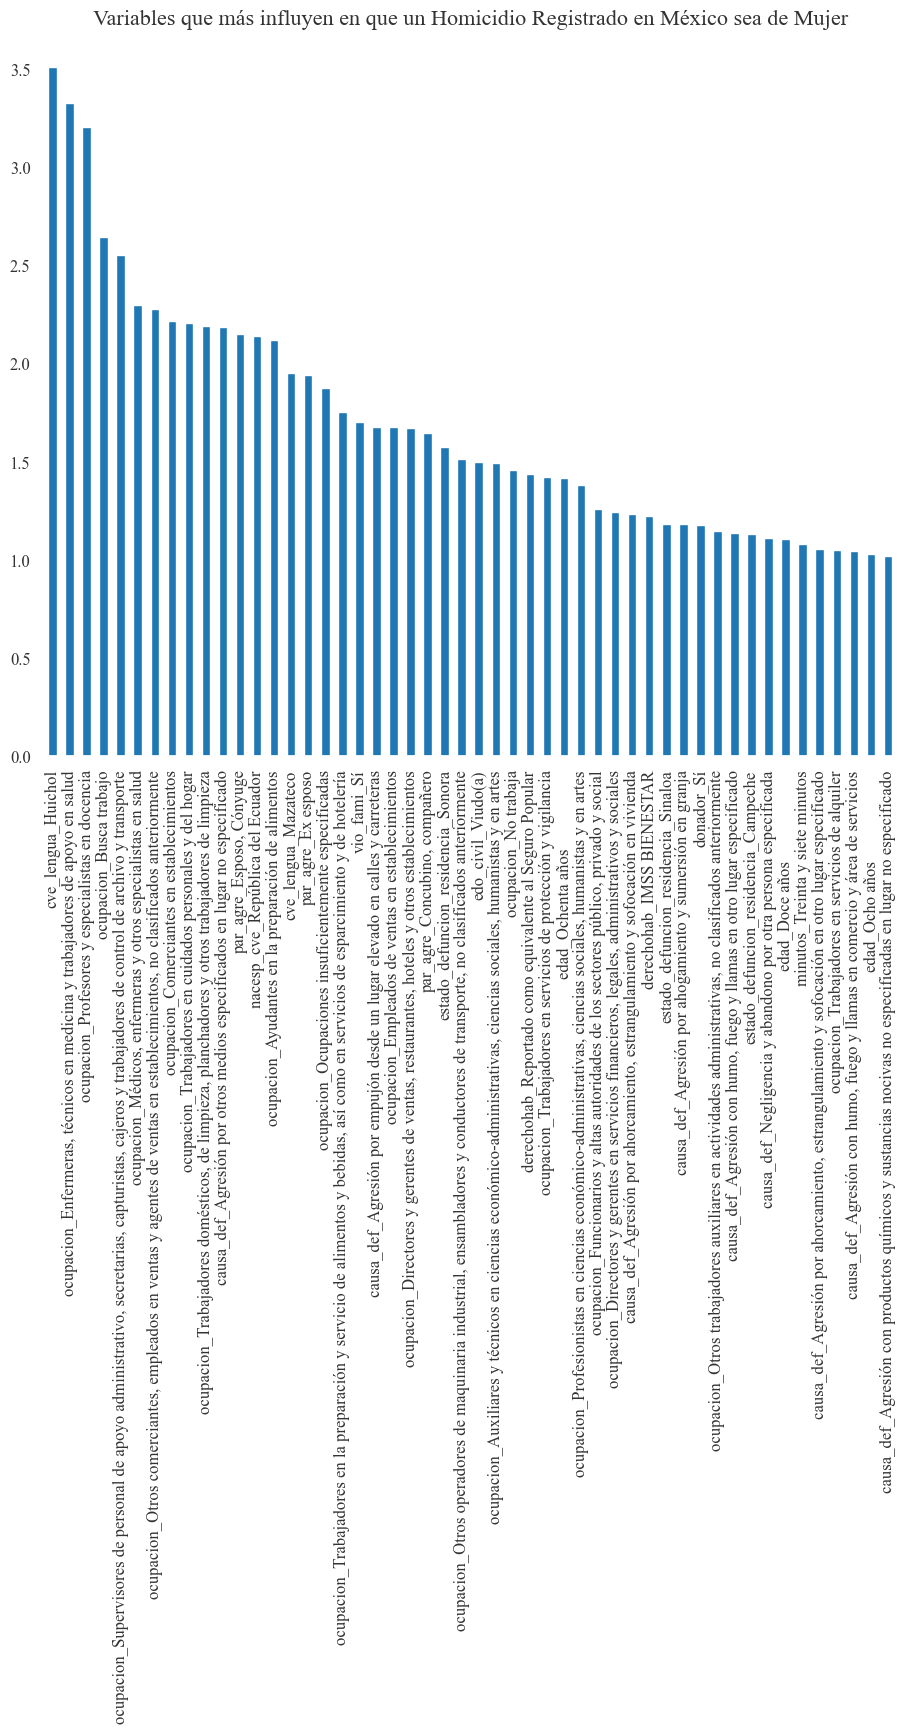

In [31]:
weights = pd.Series(model.coef_[0],
                    index=X.columns.values) 
print(weights.sort_values(ascending=False)[0:50].plot(kind='bar'))
plt.title('Variables que más influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer')

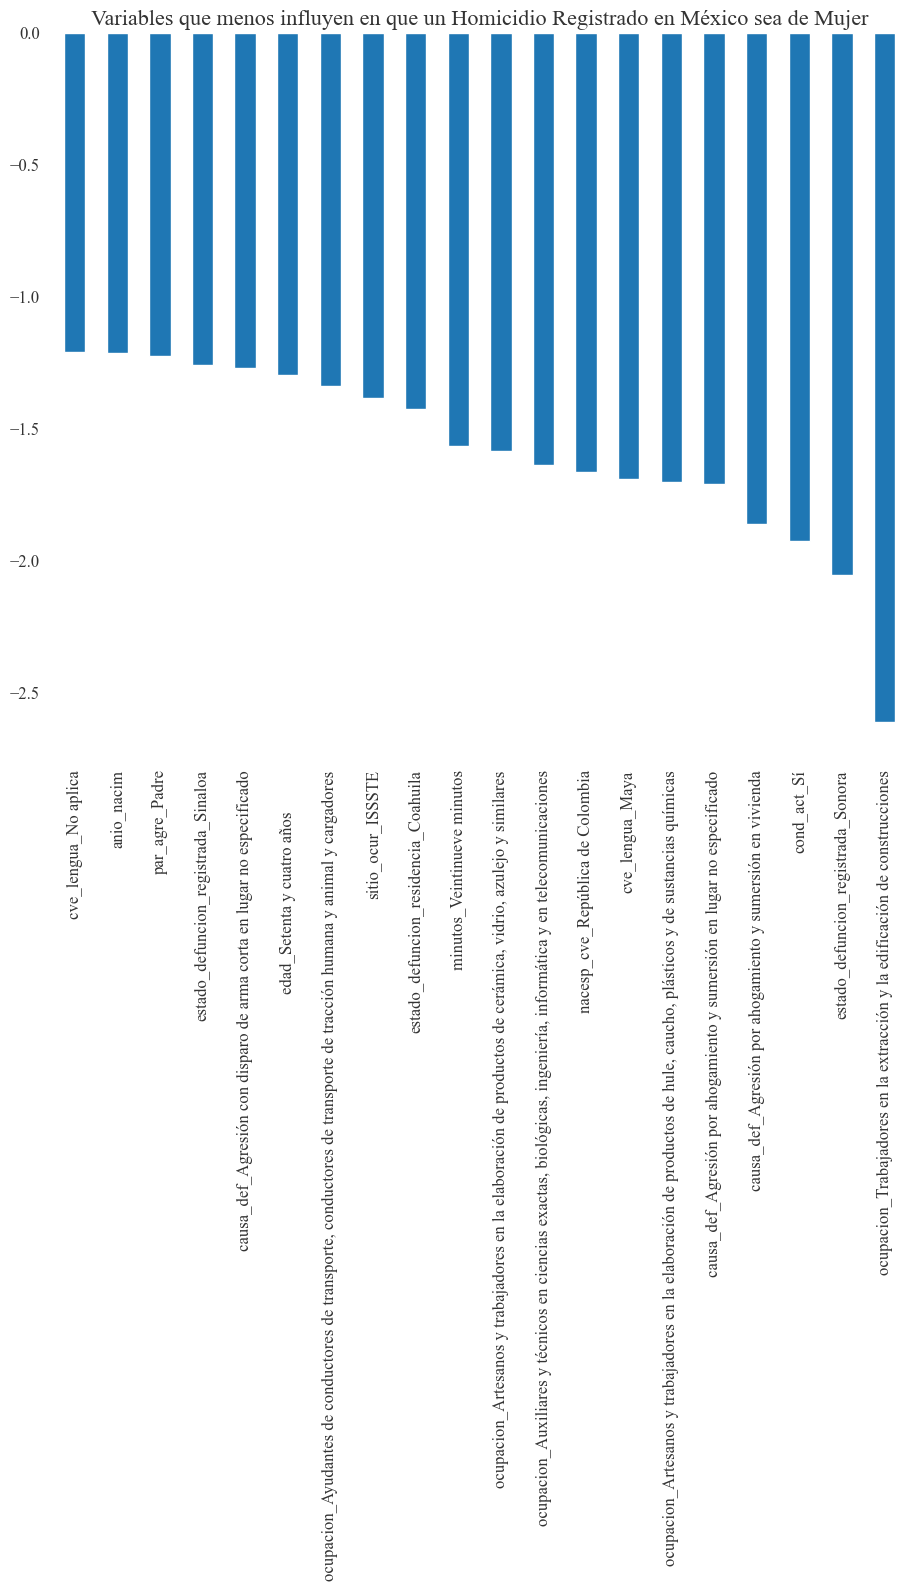

In [32]:
print(weights.sort_values(ascending=False)[-20:].plot(kind='bar'))
plt.title('Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

## Matriz de Confusión:

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

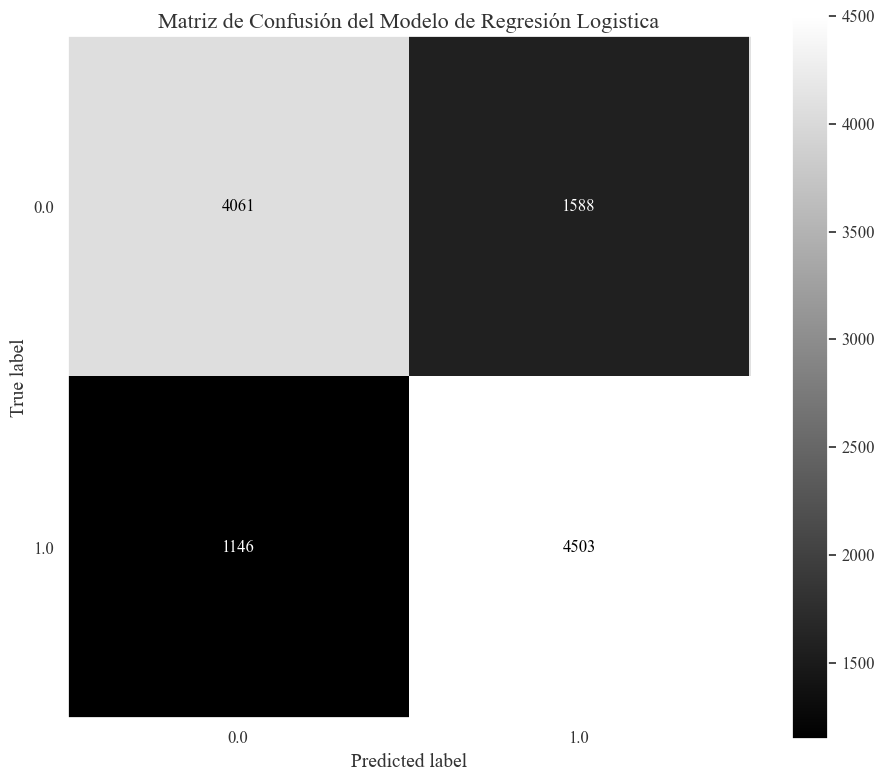

In [34]:
cm = confusion_matrix(y_test, prediction_test, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot(cmap='gray')
plt.title('Matriz de Confusión del Modelo de Regresión Logistica', size = 16)
plt.show()

In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
import numpy as np

## Definimos el Modelo:

# Inicializar validación cruzada estratificada:

In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Almacenar resultados:

In [37]:
accuracy_scores = []
balanced_acc_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)
    
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    balanced_acc_scores.append(balanced_accuracy_score(y_test_fold, y_pred_fold))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold))

## Mostrar resultados promedio:

In [38]:
print("===== Validación Cruzada (5-fold) =====")
print(f"Accuracy promedio: {np.mean(accuracy_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(balanced_acc_scores):.4f}")
print(f"F1-score promedio: {np.mean(f1_scores):.4f}")

===== Validación Cruzada (5-fold) =====
Accuracy promedio: 0.7573
Balanced Accuracy promedio: 0.7573
F1-score promedio: 0.7665


## Coeficientes:

In [39]:
feature_names = X.columns 

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nCoeficientes del Modelo de Regresión Logística:")


Coeficientes del Modelo de Regresión Logística:


In [40]:
coefficients.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Abs_Coefficient
368,"ocupacion_Enfermeras, técnicos en medicina y t...",3.420599,3.420599
156,cve_lengua_Huichol,3.295771,3.295771
387,ocupacion_Profesores y especialistas en docencia,3.188027,3.188027
129,causa_def_Agresión por otros medios especifica...,2.687070,2.687070
388,ocupacion_Supervisores de personal de apoyo ad...,2.610420,2.610420
358,ocupacion_Busca trabajo,2.570814,2.570814
372,"ocupacion_Médicos, enfermeras y otros especial...",2.400129,2.400129
440,"par_agre_Esposo, Cónyuge",2.257839,2.257839
378,"ocupacion_Otros comerciantes, empleados en ven...",2.254546,2.254546
359,ocupacion_Comerciantes en establecimientos,2.217850,2.217850


## Odds Radio:

In [41]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
print("\nOdds Ratios del Modelo de Regresión Logística:")
print(coefficients[['Feature', 'Odds_Ratio']].sort_values(by='Odds_Ratio', ascending=False))


Odds Ratios del Modelo de Regresión Logística:
                                               Feature  Odds_Ratio
368  ocupacion_Enfermeras, técnicos en medicina y t...   30.587739
156                                 cve_lengua_Huichol   26.998214
387   ocupacion_Profesores y especialistas en docencia   24.240552
129  causa_def_Agresión por otros medios especifica...   14.688571
388  ocupacion_Supervisores de personal de apoyo ad...   13.604759
..                                                 ...         ...
676                 estado_defuncion_registrada_Sonora    0.168211
349                                        cond_act_Sí    0.145962
206                   nacesp_cve_República de Colombia    0.133937
450                                     par_agre_Padre    0.129882
399  ocupacion_Trabajadores en la extracción y la e...    0.083046

[715 rows x 2 columns]


In [42]:
coefficients.sort_values(by='Coefficient', ascending=False).head(50)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
368,"ocupacion_Enfermeras, técnicos en medicina y t...",3.420599,3.420599,30.587739
156,cve_lengua_Huichol,3.295771,3.295771,26.998214
387,ocupacion_Profesores y especialistas en docencia,3.188027,3.188027,24.240552
129,causa_def_Agresión por otros medios especifica...,2.687070,2.687070,14.688571
388,ocupacion_Supervisores de personal de apoyo ad...,2.610420,2.610420,13.604759
358,ocupacion_Busca trabajo,2.570814,2.570814,13.076463
372,"ocupacion_Médicos, enfermeras y otros especial...",2.400129,2.400129,11.024599
440,"par_agre_Esposo, Cónyuge",2.257839,2.257839,9.562400
378,"ocupacion_Otros comerciantes, empleados en ven...",2.254546,2.254546,9.530968
359,ocupacion_Comerciantes en establecimientos,2.217850,2.217850,9.187552


In [43]:
coefficients.tail(20)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
266,edad_Ochenta y cinco años,-0.007594,0.007594,0.992435
188,nacesp_cve_Canadá,-0.007584,0.007584,0.992444
274,edad_Ochenta y un años,0.005529,0.005529,1.005545
174,cve_lengua_Tepehua,-0.003239,0.003239,0.996766
396,ocupacion_Trabajadores en actividades pesquera...,-0.003074,0.003074,0.996930
44,"causa_def_Agresión con disparo de rifle, escop...",-0.003045,0.003045,0.996959
638,dia_cert_Veintitrés días,-0.001778,0.001778,0.998223
432,lugar_ocur_Área industrial (taller),-0.001736,0.001736,0.998265
83,causa_def_Agresión con objeto romo o sin filo ...,-0.001696,0.001696,0.998305
219,edad_Catorce años,-0.000569,0.000569,0.999431


In [44]:
data['edad_agru'].value_counts()

edad_agru
De 25 a 29 años      4860
De 30 a 34 años      4694
De 20 a 24 años      4114
De 35 a 39 años      3886
De 40 a 44 años      3158
De 45 a 49 años      2398
No  especificada     2055
De 15 a 19 años      2002
De 50 a 54 años      1693
De 55 a 59 años      1139
De 60 a 64 años       661
De 65 a 69 años       419
De 70 a 74 años       240
De 10 a 14 años       186
De 75 a 79 años       148
De 80 a 84 años        85
De 5 a 9 años          70
Menores de un año      42
De 85 a 89 años        37
De un año              27
De 3 años              23
De 4 años              17
De 2 años              15
De 90 a 94 años        12
De 95 a 99 años         2
Name: count, dtype: int64

In [ ]:
data['asist_medi'].value_counts()

In [ ]:
coefficients[coefficients['Feature'] == 'asist_medi_Con asistencia médica']

In [ ]:
coefficients[coefficients['Feature'] == 'edad_agru_De 10 a 14 años']

In [ ]:
coefficients[coefficients['Feature'] == 'edad_agru_De 30 a 34 años']

In [ ]:
coefficients[coefficients['Feature'] == 'edad_agru_De 20 a 24 años']

In [71]:
coefficients[coefficients['Feature'] == 'estado_defuncion_registrada_México']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
667,estado_defuncion_registrada_México,0.957127,0.957127,2.604203


In [74]:
coefficients[coefficients['Feature'] == 'estado_defuncion_registrada_Yucatán']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
681,estado_defuncion_registrada_Yucatán,-0.038697,0.038697,0.962042


In [55]:
data['lugar_ocur'].value_counts()

lugar_ocur
Calle o carretera (vía pública)    15586
Se ignora                           7361
Vivienda particular                 3914
Otro                                3322
Área comercial o de servicios        856
Granja (rancho o parcela)            587
Área industrial (taller)             118
Vivienda colectiva                    93
Áreas deportivas                      80
Escuela u oficina pública             66
Name: count, dtype: int64

In [54]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Vivienda particular']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
430,lugar_ocur_Vivienda particular,0.939299,0.939299,2.558188


In [60]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Se ignora']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
428,lugar_ocur_Se ignora,0.492059,0.492059,1.635681


In [64]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Otro']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
427,lugar_ocur_Otro,-0.029121,0.029121,0.971299


In [65]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Granja (rancho o parcela)']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
426,lugar_ocur_Granja (rancho o parcela),0.141645,0.141645,1.152168


In [66]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Área industrial (taller)']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
432,lugar_ocur_Área industrial (taller),-0.001736,0.001736,0.998265


In [70]:
data['afromex'].value_counts()

afromex
No                 25682
No especificado     3129
No aplica           2951
Sí                   221
Name: count, dtype: int64

In [49]:
coefficients[coefficients['Feature'] == 'afromex_No']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio


In [50]:
coefficients[coefficients['Feature'] == 'afromex_No especificado']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
140,afromex_No especificado,-0.458052,0.458052,0.632514


In [52]:
coefficients[coefficients['Feature'] == 'afromex_No aplica']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
139,afromex_No aplica,-0.147506,0.147506,0.862857


In [53]:
coefficients[coefficients['Feature'] == 'afromex_Sí']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
141,afromex_Sí,-0.16526,0.16526,0.847673


In [78]:
if not isinstance(X_resampled, pd.DataFrame):
    X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
else:
    X_resampled_df = X_resampled.copy()

# Identificar columnas con varianza cero
cols_to_drop_variance = X_resampled_df.columns[X_resampled_df.std() < 1e-6] # Usamos un umbral pequeño para evitar problemas de flotantes

print(f"Columnas con varianza casi cero (después de SMOTE): {len(cols_to_drop_variance)} columnas")
if len(cols_to_drop_variance) > 0:
    print(cols_to_drop_variance)
    X_resampled_df_cleaned = X_resampled_df.drop(columns=cols_to_drop_variance)
else:
    X_resampled_df_cleaned = X_resampled_df.copy()

Columnas con varianza casi cero (después de SMOTE): 1 columnas
Index(['anio_regis'], dtype='object')


## Obtenemos los Valores de p: